## Try to get image patch encoding of masklets

In [3]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

using_colab = False

if using_colab:
    import torch
    import torchvision
    print("PyTorch version:", torch.__version__)
    print("Torchvision version:", torchvision.__version__)
    print("CUDA is available:", torch.cuda.is_available())
    import sys
    !{sys.executable} -m pip install opencv-python matplotlib
    !{sys.executable} -m pip install 'git+https://github.com/facebookresearch/sam2.git'

    !mkdir -p videos
    !wget -P videos https://dl.fbaipublicfiles.com/segment_anything_2/assets/bedroom.zip
    !unzip -d videos videos/bedroom.zip

    !mkdir -p ../checkpoints/
    !wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt


import os
# if using Apple MPS, fall back to CPU for unsupported ops
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image

# select the device for computation
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"using device: {device}")

if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    if torch.cuda.get_device_properties(0).major >= 8:
        torch.backends.cuda.matmul.allow_tf32 = True
        torch.backends.cudnn.allow_tf32 = True
elif device.type == "mps":
    print(
        "\nSupport for MPS devices is preliminary. SAM 2 is trained with CUDA and might "
        "give numerically different outputs and sometimes degraded performance on MPS. "
        "See e.g. https://github.com/pytorch/pytorch/issues/84936 for a discussion."
    )

using device: cuda


In [4]:
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "checkpoints/sam2.1_hiera_tiny.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        cmap_idx = 0 if obj_id is None else obj_id
        color = np.array([*cmap(cmap_idx)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)


def show_points(coords, labels, ax, marker_size=200):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)


def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0, 0, 0, 0), lw=2))


def save_segmented_image(img_folder: str, img_name: str, mask: np.ndarray, target_folder: str):
    img = np.array(Image.open(os.path.join(img_folder, img_name)))
    h, w = mask.shape[-2:]
    mask = mask.reshape(h, w)
    img[~mask] = 0
    Image.fromarray(img).save(os.path.join(target_folder, img_name))
    return img

### Select an example video

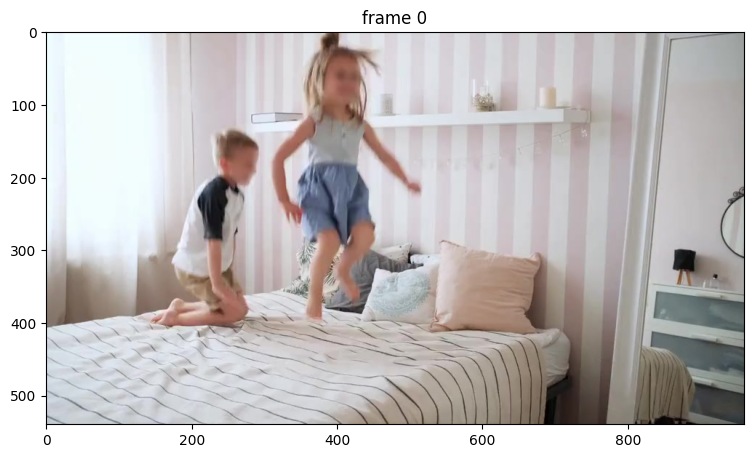

In [5]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "/app/sam2/notebooks/videos/bedroom"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

In [6]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 200/200 [00:03<00:00, 57.03it/s]


In [16]:
predictor.reset_state(inference_state)

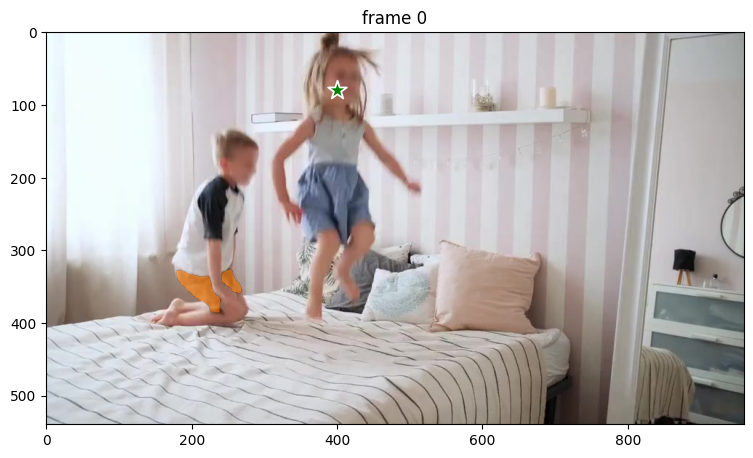

In [ ]:
ann_frame_idx = 0  # the frame index we interact with
# ann_frame_idx = 1
# ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)
ann_obj_id = 1

# Let's add a positive click at (x, y) = (210, 350) to get started
points = np.array([[210, 350]], dtype=np.float32)   # [210, 350], [400, 80], [400, 150]
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

In [19]:
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

propagate in video: 100%|██████████| 200/200 [00:08<00:00, 22.33it/s]


In [20]:
video_segments[0][1].shape

(1, 540, 960)

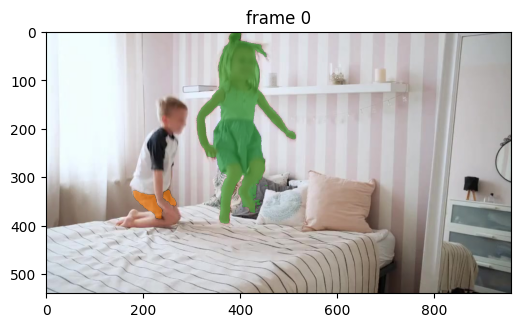

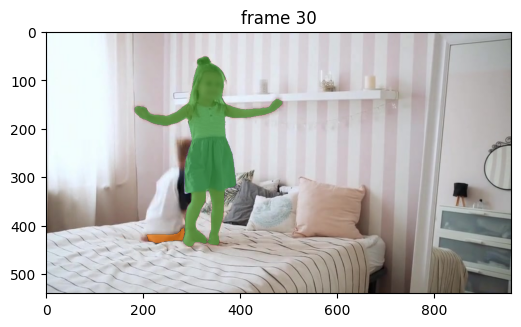

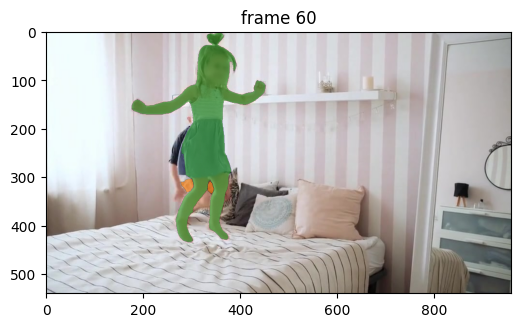

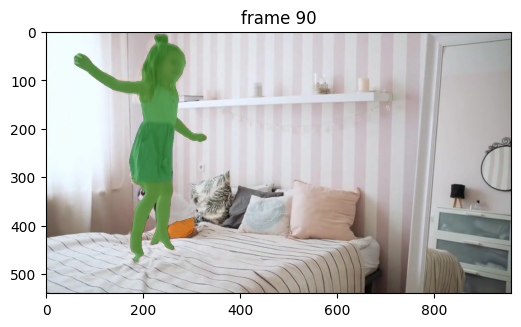

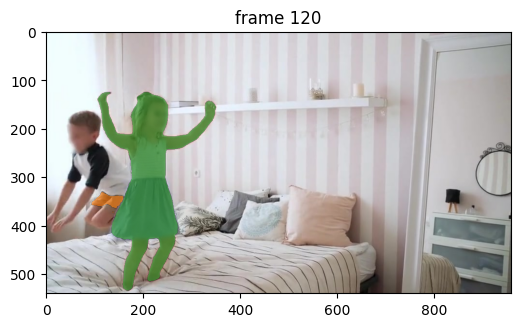

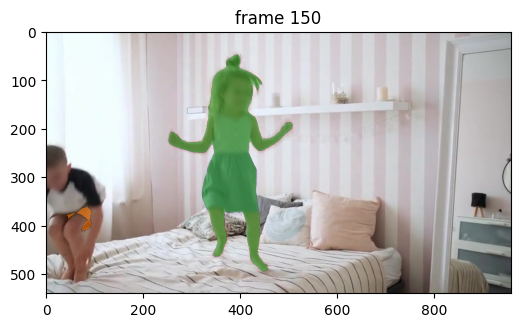

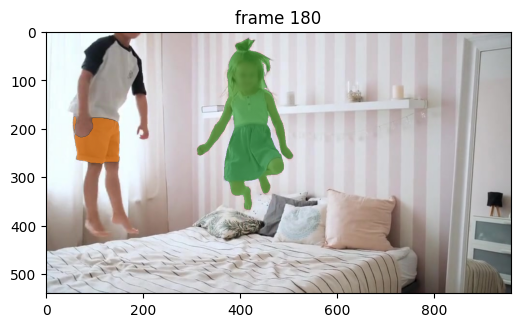

In [21]:
vis_frame_stride = 30
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)



In [23]:
# TODO: Make the propagation step by step and look if you get exposed to any usefull latent representations from
# the memory bank. Probably look out for object pointer or spatial memory features
print(inference_state.keys())
print(inference_state["output_dict_per_obj"][0].keys())
print(inference_state["output_dict_per_obj"][0]["non_cond_frame_outputs"][90]["obj_ptr"].shape)
print(inference_state["output_dict_per_obj"].keys())
# print(inference_state["output_dict"]["non_cond_frame_outputs"][90].keys())
# print(inference_state["output_dict"]["non_cond_frame_outputs"][90]["obj_ptr"].shape)

dict_keys(['images', 'num_frames', 'offload_video_to_cpu', 'offload_state_to_cpu', 'video_height', 'video_width', 'device', 'storage_device', 'point_inputs_per_obj', 'mask_inputs_per_obj', 'cached_features', 'constants', 'obj_id_to_idx', 'obj_idx_to_id', 'obj_ids', 'output_dict_per_obj', 'temp_output_dict_per_obj', 'frames_tracked_per_obj'])
dict_keys(['cond_frame_outputs', 'non_cond_frame_outputs'])
torch.Size([1, 256])
dict_keys([0, 1])


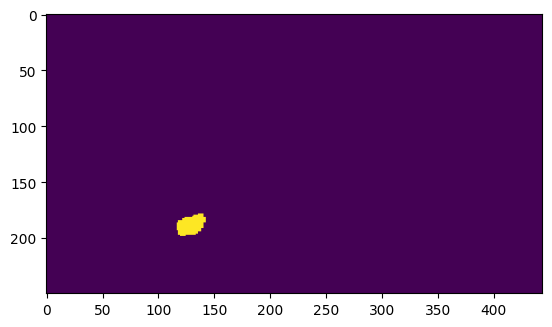

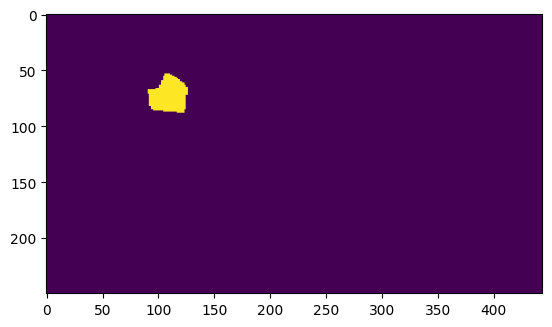

In [111]:
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

# check against mask of inference state
mask_tensor = inference_state["output_dict"]["non_cond_frame_outputs"][90]["pred_masks"]
resized_mask = F.interpolate(mask_tensor, size=(250, 444), mode='nearest')
numpy_masks = resized_mask.squeeze().cpu().numpy()
for i in range(numpy_masks.shape[0]):
    plt.imshow(numpy_masks[i] > 1.0)
    plt.show()

### Test it on a Krone video

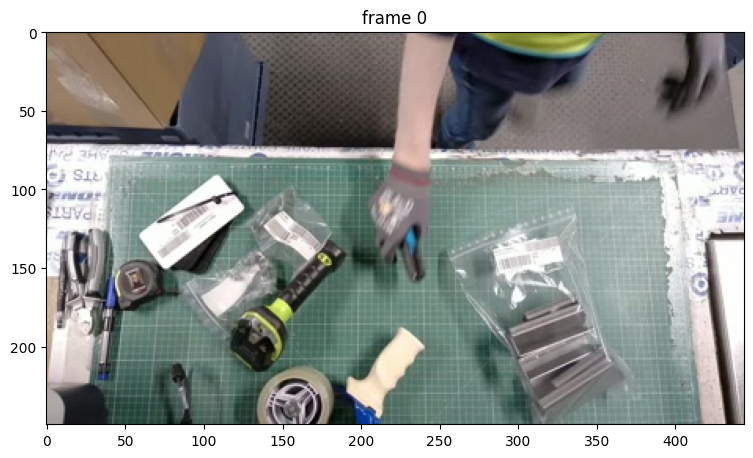

In [7]:
# `video_dir` a directory of JPEG frames with filenames like `<frame_index>.jpg`
video_dir = "/app/packtisch/frames/2024-11-12_10-56-12_cam3"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))

# take a look the first video frame
frame_idx = 0
plt.figure(figsize=(9, 6))
plt.title(f"frame {frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[frame_idx])))

In [8]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG): 100%|██████████| 533/533 [00:07<00:00, 73.07it/s]


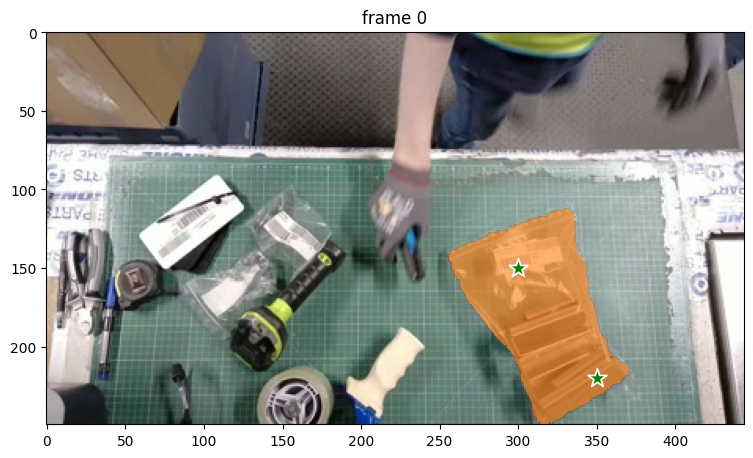

In [9]:
ann_frame_idx = 0  # the frame index we interact with
ann_obj_id = 1  # give a unique id to each object we interact with (it can be any integers)

# Let's add a positive click at (x, y) = (210, 350) to get started
points = np.array([[300, 150], [340, 1200], [140, 280], [350, 220]], dtype=np.float32)
# for labels, `1` means positive click and `0` means negative click
labels = np.array([1, 1, 1, 1], np.int32)
_, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=ann_frame_idx,
    obj_id=ann_obj_id,
    points=points,
    labels=labels,
)

# show the results on the current (interacted) frame
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[ann_frame_idx])))
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

In [10]:
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

print(out_obj_ids)

propagate in video: 100%|██████████| 533/533 [00:17<00:00, 31.35it/s]

[1]


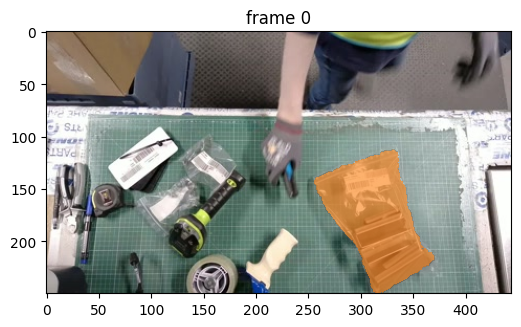

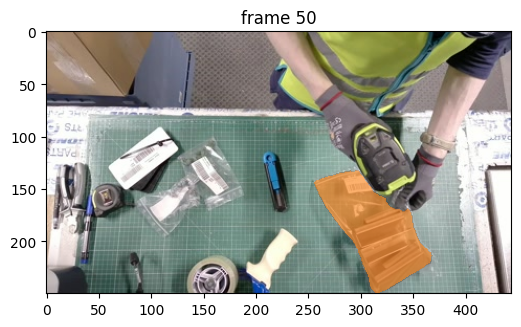

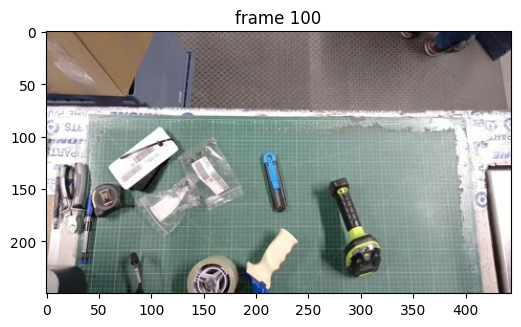

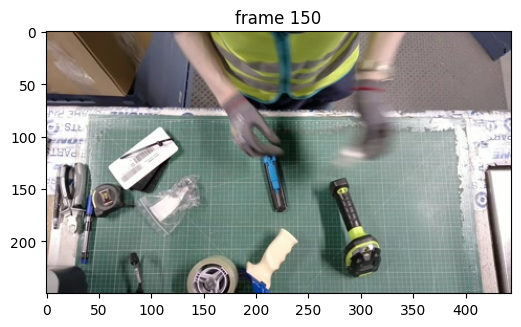

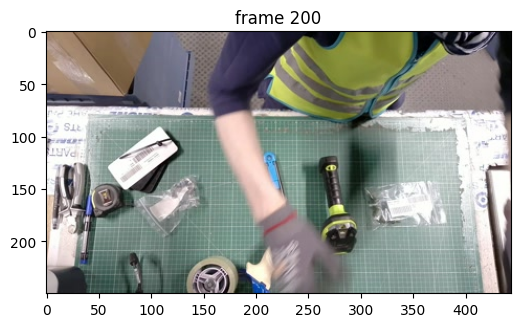

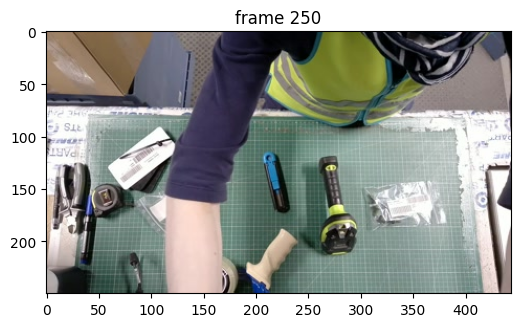

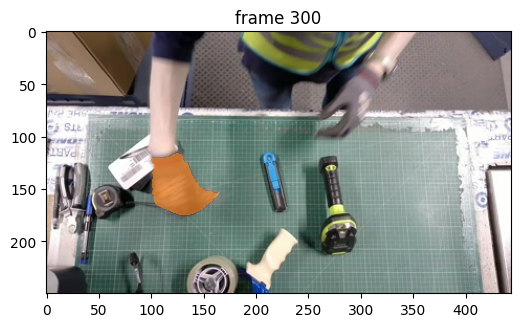

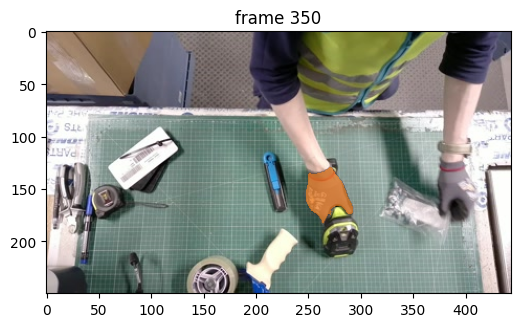

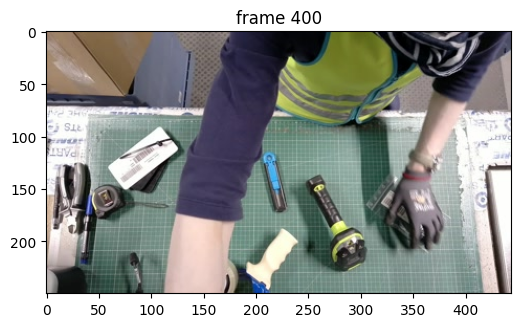

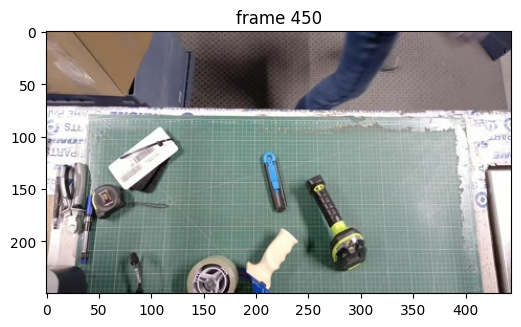

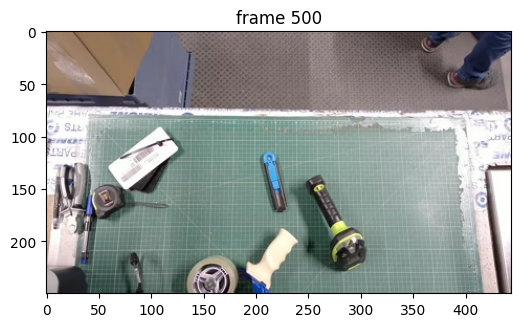

In [11]:
vis_frame_stride = 50
plt.close("all")
for out_frame_idx in range(0, len(frame_names), vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

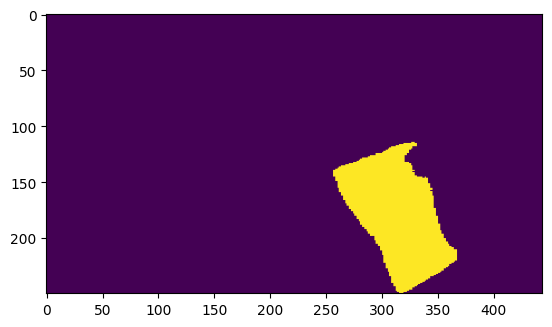

In [18]:
import matplotlib.pyplot as plt
from PIL import Image
import torch.nn.functional as F

# check against mask of inference state
mask_tensor = inference_state["output_dict"]["non_cond_frame_outputs"][3]["pred_masks"]
resized_mask = F.interpolate(mask_tensor, size=(250, 444), mode='nearest')
numpy_masks = resized_mask.squeeze().cpu().numpy()
# for i in range(numpy_masks.shape[0]):
plt.imshow(numpy_masks > 1.0)
plt.show()

In [19]:
print(inference_state.keys())
print(inference_state["output_dict"]["non_cond_frame_outputs"].keys())
print(inference_state["output_dict"]["non_cond_frame_outputs"][3].keys())
print(inference_state["output_dict"]["non_cond_frame_outputs"][3]["obj_ptr"].shape)
print(inference_state["output_dict"]["non_cond_frame_outputs"][3]["obj_ptr"])

dict_keys(['images', 'num_frames', 'offload_video_to_cpu', 'offload_state_to_cpu', 'video_height', 'video_width', 'device', 'storage_device', 'point_inputs_per_obj', 'mask_inputs_per_obj', 'cached_features', 'constants', 'obj_id_to_idx', 'obj_idx_to_id', 'obj_ids', 'output_dict', 'output_dict_per_obj', 'temp_output_dict_per_obj', 'consolidated_frame_inds', 'tracking_has_started', 'frames_already_tracked'])
dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 13

In [2]:
# Test parameters of automatic mask retrieval

import os
import sys
from PIL import Image
import numpy as np
import argparse
import joblib
import traceback
from scipy.ndimage import gaussian_filter1d

os.chdir("/app/datability/src")
import sam_util_v2 as pod_u

os.chdir("/app/SEA-RAFT")
if "/app/RAFT/core" in sys.path:
    sys.path.remove("/app/RAFT/core")
if "/app/SEA-RAFT/core" not in sys.path:
    sys.path.append("/app/SEA-RAFT/core")
from sea_raft_demo import parse_args, create_model, estimate_flow

os.chdir("/app/sam2")
from sam2.build_sam import build_sam2_video_predictor
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator


def prepare_models():
    # init optical flow model
    sea_raft_parser = argparse.ArgumentParser()
    sea_raft_parser.add_argument(
        "--cfg", help="experiment configure file name", required=True, type=str
    )
    sea_raft_parser.add_argument(
        "--path", help="checkpoint path", type=str, default=None
    )
    sea_raft_parser.add_argument("--url", help="checkpoint url", type=str, default=None)
    sea_raft_parser.add_argument(
        "--device", help="inference device", type=str, default="cpu"
    )
    args_list = [
        "--path",
        "/app/SEA-RAFT/models/SEA-RAFT-Tartan-C-T-TSKH-spring540x960-M.pth",
        "--cfg",
        "/app/SEA-RAFT/config/eval/spring-M.json",
        "--device",
        "cuda",
    ]
    sea_raft_args = parse_args(sea_raft_parser, args_list)
    sea_raft_model = create_model(sea_raft_args)

    # init segmentation model
    sam2_checkpoint = "checkpoints/sam2.1_hiera_tiny.pt"
    model_cfg = "configs/sam2.1/sam2.1_hiera_t.yaml"
    device = "cuda"
    sam2_predictor = build_sam2_video_predictor(
        model_cfg, sam2_checkpoint, device=device
    )

    return (
        sea_raft_model,
        sea_raft_args,
        sam2_predictor,
    )


def estimate_flow_on_images(sea_raft_model, sea_raft_args, image_filenames):
    # call flow model
    flows, flow_vizs, heatmaps, heatmap_vizs = zip(
        *[
            estimate_flow(
                sea_raft_model,
                sea_raft_args,
                image_filenames[i],
                image_filenames[i + 1],
                device="cuda",
            )
            for i in range(len(image_filenames) - 1)
        ]
    )
    # Convert tensors to NumPy arrays
    flows = [flow.squeeze().cpu().numpy().transpose((1, 2, 0)) for flow in flows]
    flow_vizs = list(flow_vizs)
    heatmaps = [heatmap.squeeze().cpu().numpy() for heatmap in heatmaps]
    heatmap_vizs = list(heatmap_vizs)

    return flows, flow_vizs, heatmaps, heatmap_vizs


def segment_image(
    image: Image,
    flow: np.ndarray,
    sam2_predictor,
    iou_treshold: int = 0.75,
    size_treshold: int = 1000,
):
    normed_flow = np.linalg.norm(flow, axis=2)
    tresh_flow = normed_flow > 1

    filtered_sampling_points = pod_u.get_fitted_sampling_points(
        tresh_flow, points_per_side=32
    )
    # sam2_mask_generator = SAM2AutomaticMaskGenerator(sam2_predictor, pred_iou_thresh=0.7, stability_score_thresh=0.9, point_grids=[filtered_sampling_points], points_per_side=None)
    # sam2_mask_generator = SAM2AutomaticMaskGenerator(sam2_predictor, pred_iou_thresh=0.85, stability_score_thresh=0.9, point_grids=[filtered_sampling_points], points_per_side=None, min_mask_region_area=100)
    sam2_mask_generator = SAM2AutomaticMaskGenerator(
        sam2_predictor,
        pred_iou_thresh=0.75,
        stability_score_thresh=0.2,
        stability_score_offset=1,
        box_nms_thresh=0.3,
        point_grids=[filtered_sampling_points],
        points_per_side=None,
        min_mask_region_area=500,
    )

    masks = sam2_mask_generator.generate(np.array(image.convert("RGB")))

    segmentation_masks = [m["segmentation"] for m in masks]

    pod_u.plot_image_flow_seg_mask(image, Image.fromarray(np.zeros_like(np.array(image))), tresh_flow, segmentation_masks)

    segmentation_masks = pod_u.post_process_masks(
        segmentation_masks, iou_treshold=iou_treshold, size_treshold=size_treshold
    )

    # intersect flow and seg
    # Don't need to filter strictly with iou as all segmentation masks originated from sample points within optical flow treshold
    moving_masks, bounding_boxes = pod_u.intersect_flow_seg(
        segmentation_masks,
        tresh_flow,
        bounding_box_bloat=2,
        intersection_treshold=0.35,
    )

    old_boxes = bounding_boxes.copy()

    boxes, mask_centers = pod_u.reorder_masks_compute_mask_centers(
        moving_masks, bounding_boxes
    )
    return moving_masks, boxes, mask_centers, old_boxes


def propagate_mask_through_video(
    image_index: int, boxes, sam2_predictor, inference_state
):
    # TODO: Is it okey to comment this here? Don't think so
    sam2_predictor.reset_state(inference_state)

    ann_obj_id = list(range(1, len(boxes) + 1))
    # colors = ["orange", "green", "red", "blue"]

    _, out_obj_ids, out_mask_logits = zip(
        *[
            sam2_predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=image_index,
                obj_id=ann_obj_id[i],
                # points=points,
                # labels=labels,
                box=boxes[i],
            )
            for i in range(len(boxes))
        ]
    )

    # call sam2 for mask propagating through whole video snippet
    video_segments = {}  # video_segments contains the per-frame segmentation results
    # backward
    for (
        out_frame_idx,
        out_obj_ids,
        out_mask_logits,
    ) in sam2_predictor.propagate_in_video(
        inference_state, start_frame_idx=image_index, reverse=True
    ):
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy().squeeze()
            for i, out_obj_id in enumerate(out_obj_ids)
        }
    # forward
    for (
        out_frame_idx,
        out_obj_ids,
        out_mask_logits,
    ) in sam2_predictor.propagate_in_video(
        inference_state, start_frame_idx=image_index, reverse=False
    ):  # not reverse means forward
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy().squeeze()
            for i, out_obj_id in enumerate(out_obj_ids)
        }

    return video_segments


def propagate_all_once(
    image_indices: list[int], boxes: list, sam2_predictor, inference_state
):
    sam2_predictor.reset_state(inference_state)

    ann_obj_id = list(range(1, len(boxes) + 1))
    # colors = ["orange", "green", "red", "blue"]

    _, out_obj_ids, out_mask_logits = zip(
        *[
            sam2_predictor.add_new_points_or_box(
                inference_state=inference_state,
                frame_idx=image_indices[i],
                obj_id=ann_obj_id[i],
                # points=points,
                # labels=labels,
                box=boxes[i],
            )
            for i in range(len(boxes))
        ]
    )

    # call sam2 for mask propagating through whole video snippet
    video_segments = {}  # video_segments contains the per-frame segmentation results
    # backward
    for (
        out_frame_idx,
        out_obj_ids,
        out_mask_logits,
    ) in sam2_predictor.propagate_in_video(
        inference_state, start_frame_idx=np.max(image_indices), reverse=True
    ):  # start reverse tracking from the last annotated image
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy().squeeze()
            for i, out_obj_id in enumerate(out_obj_ids)
        }
    # forward
    for (
        out_frame_idx,
        out_obj_ids,
        out_mask_logits,
    ) in sam2_predictor.propagate_in_video(
        inference_state, start_frame_idx=np.min(image_indices), reverse=False
    ):  # start forward tracking from the first annotated image
        video_segments[out_frame_idx] = {
            out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy().squeeze()
            for i, out_obj_id in enumerate(out_obj_ids)
        }

    return video_segments


def add_masklets_and_pointers_to_dict(
    video_segments: dict,
    inference_state: dict,
    object_dict: dict,
    pointers_dict: dict,
    num_found_objects: int,
):
    object_id_mapping = {
        i: i + num_found_objects for i in range(1, len(video_segments[0].keys()) + 1)
    }

    for frame_number, frame_masklets in video_segments.items():
        frame_outputs_key = (
            "non_cond_frame_outputs"
            if frame_number
            in inference_state["output_dict"]["non_cond_frame_outputs"].keys()
            else "cond_frame_outputs"
        )

        object_pointers = inference_state["output_dict"][frame_outputs_key][
            frame_number
        ]["obj_ptr"]

        for i, (obj_id, obj_mask) in enumerate(frame_masklets.items()):
            object_dict[frame_number][object_id_mapping[obj_id]] = obj_mask
            pointers_dict[frame_number][object_id_mapping[obj_id]] = object_pointers[i]

    num_found_objects += len(video_segments[0].keys())
    return num_found_objects


def add_all_masklets_and_pointers_to_dict(
    video_segments: dict, inference_state: dict, object_dict: dict, pointers_dict: dict
):
    for frame_number, frame_masklets in video_segments.items():
        frame_outputs_key = (
            "non_cond_frame_outputs"
            if frame_number
            in inference_state["output_dict"]["non_cond_frame_outputs"].keys()
            else "cond_frame_outputs"
        )
        object_pointers = inference_state["output_dict"][frame_outputs_key][
            frame_number
        ]["obj_ptr"].squeeze(0)
        for i in sorted(frame_masklets.keys()):
            object_dict[frame_number][i] = frame_masklets[i]
            try:
                pointers_dict[frame_number][i] = object_pointers[i]
            except:
                pointers_dict[frame_number][i] = np.nan


def convert_dicts_to_arrays(
    object_dict: dict, pointers_dict: dict, num_found_objects: int, img_size: tuple[int]
):
    # Do this at the end once to convert the dict of frame_number, object_id to a list of
    # object_id, frame_number
    H, W = img_size

    object_array = np.empty((num_found_objects, len(object_dict), H, W), dtype=int)
    pointers_array = np.empty((num_found_objects, len(object_dict), 256), dtype=float)

    for frame_number, frame_masklets in sorted(object_dict.items()):
        for obj_id, (obj_mask, obj_ptr) in enumerate(
            zip(frame_masklets.values(), pointers_dict[frame_number].values())
        ):
            # object_array[obj_id - 1][frame_number] = obj_mask
            # pointers_array[obj_id - 1][frame_number] = obj_ptr.cpu().numpy()
            object_array[obj_id][frame_number] = obj_mask
            pointers_array[obj_id][frame_number] = obj_ptr.cpu().numpy()

    return object_array, pointers_array


def convert_dicts_to_arrays_in_order(
    object_dict: dict, pointers_dict: dict, img_size: tuple[int]
):
    # Do this at the end once to convert the dict of frame_number, object_id to a list of
    # object_id, frame_number
    H, W = img_size
    num_images = len(object_dict)
    num_found_objects = len(object_dict[0])

    object_array = np.empty((num_found_objects, num_images, H, W), dtype=int)
    pointers_array = np.empty((num_found_objects, num_images, 256), dtype=float)

    # for frame_number, frame_masklets in sorted(object_dict.items()):
    #     for obj_id, (obj_mask, obj_ptr) in enumerate(zip(frame_masklets.values(), pointers_dict[frame_number].values())):
    #         object_array[obj_id-1][frame_number] = obj_mask
    #         pointers_array[obj_id-1][frame_number] = obj_ptr.cpu().numpy()
    for frame_number in sorted(object_dict.keys()):
        frame_masklets = object_dict[frame_number]
        frame_pointers = pointers_dict[frame_number]
        for i, obj_id in enumerate(sorted(frame_masklets.keys())):
            object_array[i][frame_number] = frame_masklets[obj_id]
            pointers_array[i][frame_number] = frame_pointers[obj_id].cpu().numpy()

    return object_array, pointers_array


def match_masks_against_known_masks(
    new_masks: list, known_masks: dict, iou_threshold: float = 0.5
):
    unseen_masks_indices = list()
    known_mask_keys_to_remove = list()
    for i, new_mask in enumerate(new_masks):
        unseen = True
        for obj_id, known_mask in known_masks.items():
            if (
                np.logical_and(new_mask, known_mask).sum()
                / np.logical_or(new_mask, known_mask).sum()
                > iou_threshold
            ):
                if np.sum(new_mask) / np.sum(known_mask) <= 0.75:
                    # Remove known, bigger mask for smaller, more crisp mask
                    known_mask_keys_to_remove.append(obj_id)
                else:
                    # Else just don't track the newly found one
                    unseen = False
                    break
        if unseen:
            unseen_masks_indices.append(i)

    return unseen_masks_indices, known_mask_keys_to_remove


def find_zero_crossings(signal: np.ndarray):
    """
    Finds the indices where the signal crosses zero.
    """
    sign_changes = np.sign(signal[:-1]) * np.sign(
        signal[1:]
    )  # Check sign change between samples
    zero_crossings = np.where(sign_changes < 0)[0]  # Indices where sign change happens
    return zero_crossings


def get_most_relevant_images(flows, k: int = 10):
    """
    Returns ``k`` image indices of zero crossings of the first derivative with the highest
    absolute values of the second derivative.
    """
    flow_norm_mean = np.mean(
        np.linalg.norm(flows, axis=-1), axis=(1, 2)
    )  # compute mean of flow norm
    flow_norm_mean = gaussian_filter1d(flow_norm_mean, sigma=3)  # smooth flow

    # compute derivatives
    flow_norm_grad = np.gradient(flow_norm_mean)
    flow_norm_grad_grad = np.gradient(flow_norm_grad)

    zero_crossing_grad = find_zero_crossings(flow_norm_grad)

    # get k strongest zero crossings
    best_zero_crossings_grad = np.argsort(
        -np.abs(flow_norm_grad_grad[zero_crossing_grad])
    )[:k]
    best_zero_crossings_grad = zero_crossing_grad[best_zero_crossings_grad]

    return best_zero_crossings_grad


def remove_non_table_objects(
    moving_masks: list, boxes: list, mask_centers: list, old_boxes: list
):
    table_object_indices = [
        i
        for i in range(len(mask_centers))
        if mask_centers[i][1] >= 80 and mask_centers[i][0] <= 412
    ]
    moving_masks = [moving_masks[i] for i in table_object_indices]
    boxes = [boxes[i] for i in table_object_indices]
    mask_centers = [mask_centers[i] for i in table_object_indices]
    old_boxes = [old_boxes[i] for i in table_object_indices]

    return moving_masks, boxes, mask_centers, old_boxes


def main(
    image_filenames: list[str],
    sea_raft_model,
    sea_raft_args,
    sam2_predictor,
    # mask_diff_model_path: str,
    top_k_zero_crossings: int = 10,
):
    # sea_raft_model, sea_raft_args, sam2_predictor, inference_state, mask_diff_model = (
    #     prepare_models_input(image_filenames, mask_diff_model_path)
    # )
    # TODO: Use mask diff model for inferring mask types

    # prepare images and load it into sam2
    tmp_folder = "/app/packtisch/tmp_sam2_folder"
    image_filenames = pod_u.clean_and_copy_images(tmp_folder, image_filenames)
    inference_state = sam2_predictor.init_state(
        video_path=tmp_folder, async_loading_frames=False
    )

    flows, flow_vizs, heatmaps, heatmap_vizs = estimate_flow_on_images(
        sea_raft_model, sea_raft_args, image_filenames
    )

    # TODO: Add back in if need to restrain flow
    # crop flow to image segment containing the table
    for i in range(len(flows)):
        flows[i][0:80, :, :] = np.array([0, 0])
        flows[i][:, 412:, :] = np.array([0, 0])

    img_size = flows[0].shape[0:2]  # H, W

    # init object_dict for all frames
    object_dict, pointers_dict = dict(), dict()
    num_found_objects = 0
    for i in range(len(image_filenames)):
        object_dict[i] = dict()
        pointers_dict[i] = dict()

    # for image_index in range(len(image_filenames) - 1): # Got one less flow image than actual images. Here, just don't look at the last image
    for image_index in get_most_relevant_images(
        flows, k=top_k_zero_crossings
    ):  # only look at k best images based on flow
        # print(image_index)
        # get moving object masks from image
        image = Image.open(image_filenames[image_index])
        flow = flows[image_index]
        try:
            moving_masks, boxes, mask_centers, old_boxes = segment_image(
                image, flow, sam2_predictor, iou_treshold=0.75, size_treshold=150
            )
        except Exception as e:
            print("Caught an exception during single image segmentation:")
            traceback.print_exc()
            continue

        # remove masks that are not centered on table
        moving_masks, boxes, mask_centers, old_boxes = remove_non_table_objects(
            moving_masks, boxes, mask_centers, old_boxes
        )

        # discard masks we already saw
        unseen_indices, known_mask_keys_to_remove = match_masks_against_known_masks(
            moving_masks, object_dict[image_index], iou_threshold=0.5
        )
        moving_masks = [moving_masks[i] for i in unseen_indices]
        boxes = [boxes[i] for i in unseen_indices]
        old_boxes = [old_boxes[i] for i in unseen_indices]
        mask_centers = [mask_centers[i] for i in unseen_indices]

        # delete the object in every frame
        # for k in known_mask_keys_to_remove:
        #     for v in object_dict.values():
        #         del v[k]

        # plot all filtered boxes
        pod_u.plot_image_bounding_box_and_mask(image, moving_masks, old_boxes)

        # if nothing new is found in image, continue
        if len(moving_masks) == 0:
            continue

        # propagate new masks through image
        # video_segments = propagate_mask_through_video(
        #     image_index, boxes, sam2_predictor, inference_state
        # )
        # num_found_objects = add_masklets_and_pointers_to_dict(
        #     video_segments,
        #     inference_state,
        #     object_dict,
        #     pointers_dict,
        #     num_found_objects,
        # )

        # pod_u.plot_sam2_masks_propagation(image_filenames, video_segments, vis_frame_stride=25)

    # print("Final masks:")
    # pod_u.plot_sam2_masks_propagation(image_filenames, object_dict, vis_frame_stride=25)

    # Do this at the end once to convert the dict of frame_number, object_id to a list
    # of object_id, frame_number
    object_array, pointers_array = convert_dicts_to_arrays(
        object_dict, pointers_dict, num_found_objects, img_size
    )

    return object_array, pointers_array, inference_state, image_filenames


['/app/packtisch/frames/2024-11-12_08-50-32_cam3/0002.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0003.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0004.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0005.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0006.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0007.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0008.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0009.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0010.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0011.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0012.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0013.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0014.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0015.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0016.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0017.jpg', '/app/packtisch/frames/2024-11-12_08-50-32_cam3/0018.jp

frame loading (JPEG): 100%|██████████| 298/298 [00:04<00:00, 70.87it/s]
/opt/conda/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/app/sam2/sam2/modeling/sam/transformer.py:270: UserWarning: Memory efficient kernel not used because: (Triggered internally at ../aten/src/ATen/native/transformers/cuda/sdp_utils.cpp:773.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
/app/sam2/sam2/modeling/sam/transformer.py:270: UserWarning: Memory Efficient attention has been runtime disabled. (Triggered internally at ../aten/src/ATen/native/transformers/sdp_utils_cpp.h:558.)
  out = F.scaled_dot_product_attention(q, k, v, dropout_p=dropout_p)
/app/sam2/sam2/modeling/sam/transformer.py:270: UserWarning: Flash attention kernel not u

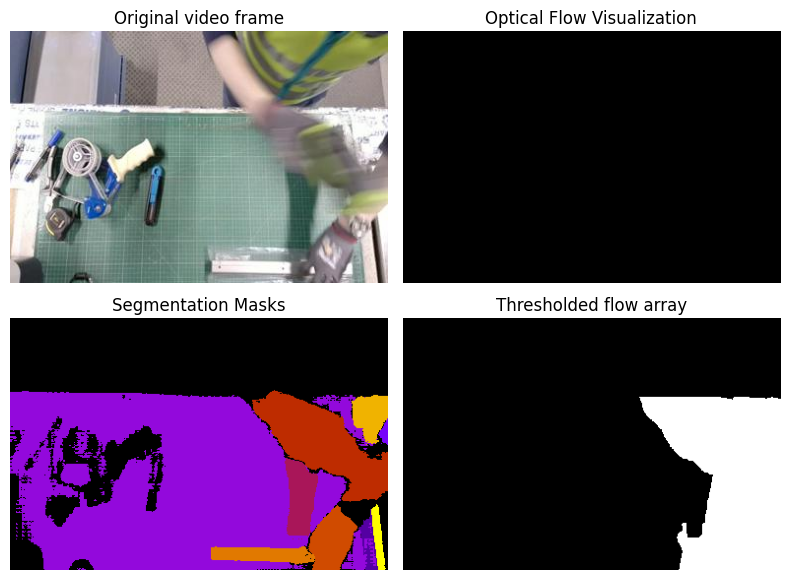

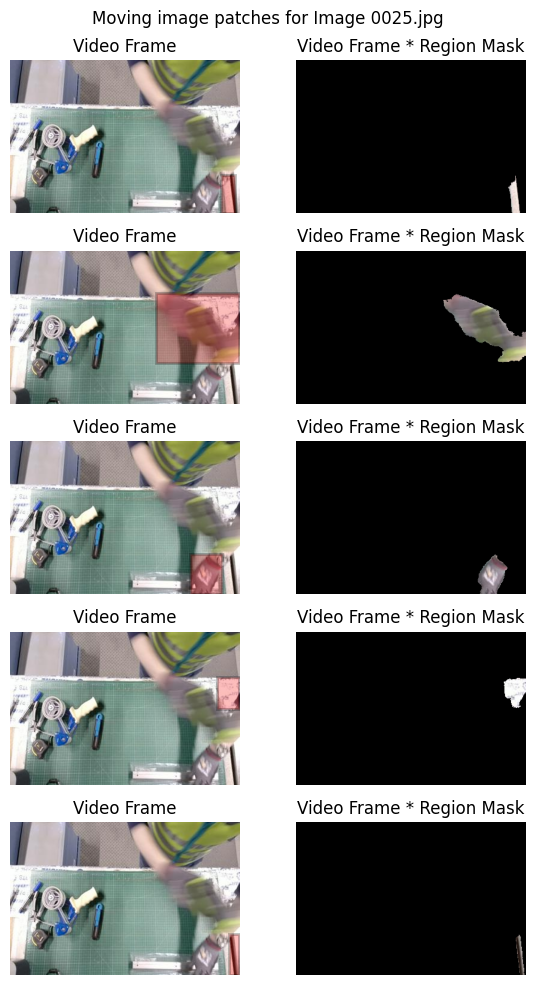

/app/sam2/sam2/sam2_image_predictor.py:431: UserWarning: cannot import name '_C' from 'sam2' (/app/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  masks = self._transforms.postprocess_masks(


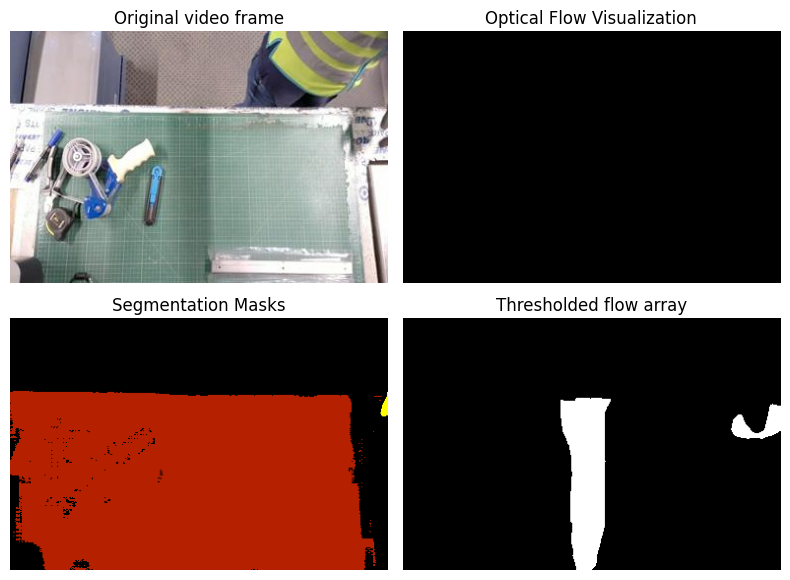

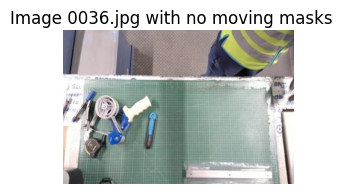

Caught an exception during single image segmentation:


Traceback (most recent call last):
  File "/tmp/ipykernel_717/2153856962.py", line 473, in main
    moving_masks, boxes, mask_centers, old_boxes = segment_image(
                                                   ^^^^^^^^^^^^^^
  File "/tmp/ipykernel_717/2153856962.py", line 119, in segment_image
    pod_u.plot_image_flow_seg_mask(image, Image.fromarray(np.zeros_like(np.array(image))), tresh_flow, segmentation_masks)
  File "/app/datability/src/sam_util_v2.py", line 56, in plot_image_flow_seg_mask
    labeled_array = np.zeros_like(seg_masks[0], dtype=int)
                                  ~~~~~~~~~^^^
IndexError: list index out of range


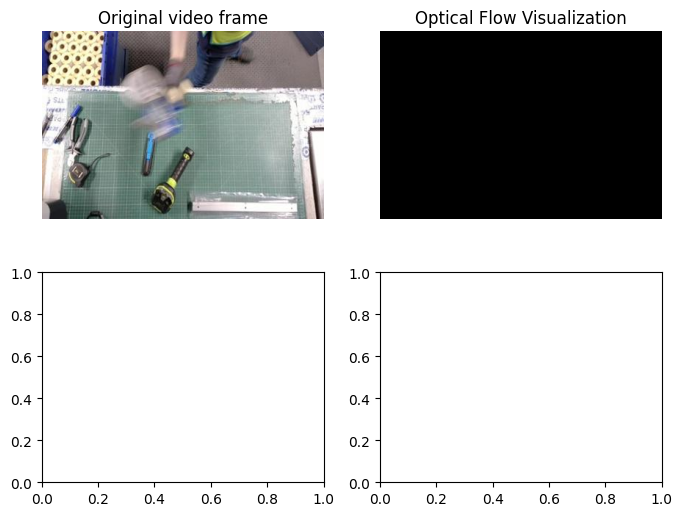

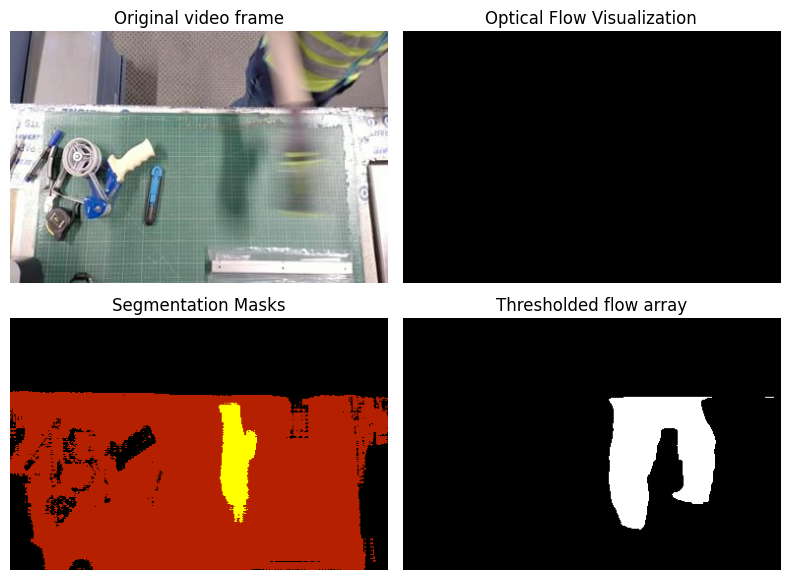

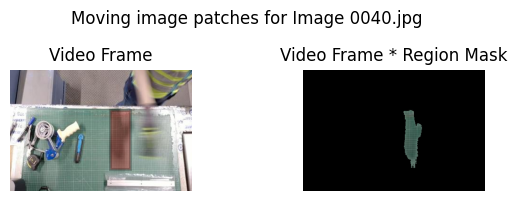

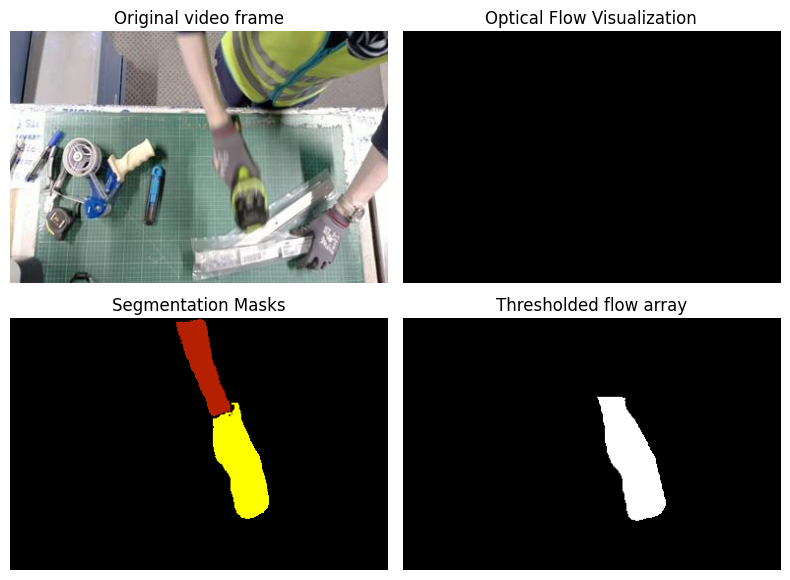

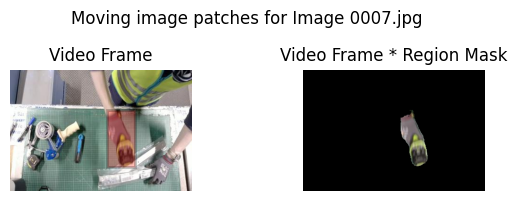

Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:


Traceback (most recent call last):
  File "/tmp/ipykernel_717/2153856962.py", line 473, in main
    moving_masks, boxes, mask_centers, old_boxes = segment_image(
                                                   ^^^^^^^^^^^^^^
  File "/tmp/ipykernel_717/2153856962.py", line 115, in segment_image
    masks = sam2_mask_generator.generate(np.array(image.convert("RGB")))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/_contextlib.py", line 116, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/app/sam2/sam2/automatic_mask_generator.py", line 196, in generate
    mask_data = self._generate_masks(image)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/sam2/sam2/automatic_mask_generator.py", line 233, in _generate_masks
    crop_data = self._process_crop(image, crop_box, layer_idx, orig_size)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:


Traceback (most recent call last):
  File "/tmp/ipykernel_717/2153856962.py", line 473, in main
    moving_masks, boxes, mask_centers, old_boxes = segment_image(
                                                   ^^^^^^^^^^^^^^
  File "/tmp/ipykernel_717/2153856962.py", line 115, in segment_image
    masks = sam2_mask_generator.generate(np.array(image.convert("RGB")))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/_contextlib.py", line 116, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/app/sam2/sam2/automatic_mask_generator.py", line 196, in generate
    mask_data = self._generate_masks(image)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/sam2/sam2/automatic_mask_generator.py", line 233, in _generate_masks
    crop_data = self._process_crop(image, crop_box, layer_idx, orig_size)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:
Caught an exception during single image segmentation:


Traceback (most recent call last):
  File "/tmp/ipykernel_717/2153856962.py", line 473, in main
    moving_masks, boxes, mask_centers, old_boxes = segment_image(
                                                   ^^^^^^^^^^^^^^
  File "/tmp/ipykernel_717/2153856962.py", line 115, in segment_image
    masks = sam2_mask_generator.generate(np.array(image.convert("RGB")))
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/conda/lib/python3.11/site-packages/torch/utils/_contextlib.py", line 116, in decorate_context
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/app/sam2/sam2/automatic_mask_generator.py", line 196, in generate
    mask_data = self._generate_masks(image)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/app/sam2/sam2/automatic_mask_generator.py", line 233, in _generate_masks
    crop_data = self._process_crop(image, crop_box, layer_idx, orig_size)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [3]:
import glob

n = 1   # image step size
video_dir_name = "2024-11-12_08-50-32_cam3"
mask_diff_model_path = "/app/datability/mask_discrimination_models/radius_neifghbor_classifier.pkl"
# Remove first few frames?
# image_filenames = sorted(glob.glob("/app/packtisch/frames/2024-11-12_07-47-08_cam3/*.jpg"))[2:-2:n]
# image_filenames = sorted(glob.glob("/app/packtisch/frames/2024-11-12_09-07-33_cam3/*.jpg"))[2:-2:n]
image_filenames = sorted(glob.glob(f"/app/packtisch/frames/{video_dir_name}/*.jpg"))[2:-2:n]
print(image_filenames)
k = int(0.075 * len(image_filenames))    # top images to look at
print(f"k = {k}")
# found_objects_array, pointers_array, inference_state = pod_main.main(image_filenames, mask_diff_model_path, top_k_zero_crossings=k)
sea_raft_model, sea_raft_args, sam2_predictor = prepare_models()
object_array, pointers_array, inference_state, image_filenames = main(image_filenames, sea_raft_model, sea_raft_args, sam2_predictor, top_k_zero_crossings=k)